# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

(912, 13)
<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 92.8 KB
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0

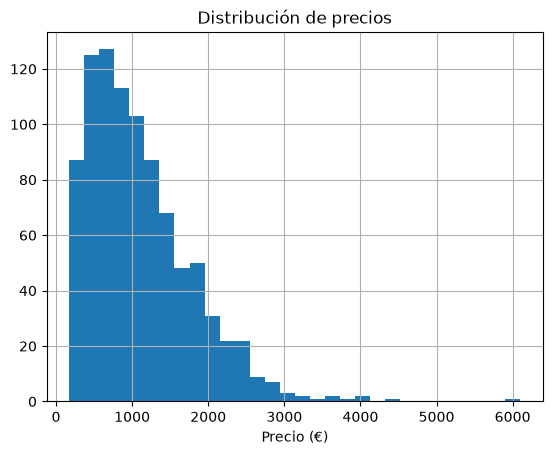

Company
Lenovo       202
Dell         197
HP           194
Asus         121
Acer          74
MSI           37
Toshiba       34
Apple         17
Razer          6
Mediacom       6
Samsung        5
Microsoft      5
Xiaomi         3
Chuwi          2
Huawei         2
Google         2
Vero           2
Fujitsu        2
LG             1
Name: count, dtype: int64

In [4]:
# Primer vistazo
print(df.shape)
df.info()

print(df.isnull().sum())  # parece que no hay nulos, bien

print(df.describe())

df['Price_in_euros'].hist(bins=30)
plt.title('Distribución de precios')
plt.xlabel('Precio (€)')
plt.show()

df['Company'].value_counts()

### 2.2 Definir X e y


In [5]:
# limpio las columnas de texto para poder usarlas
# esto lo tengo que hacer tambien en test.csv, por eso hago una funcion

def procesar_datos(data):
    data = data.copy()

    # "8GB" -> 8
    data['Ram'] = data['Ram'].str.replace('GB', '').astype(int)

    # "1.86kg" -> 1.86
    data['Weight'] = data['Weight'].str.replace('kg', '').astype(float)

    # marca y velocidad de la Cpu
    data['Cpu_brand'] = data['Cpu'].apply(lambda x: x.split()[0])
    data['Cpu_speed'] = data['Cpu'].apply(lambda x: float(re.findall(r'([\d\.]+)GHz', x)[0]))

    # marca de la Gpu
    data['Gpu_brand'] = data['Gpu'].apply(lambda x: x.split()[0])

    # si tiene pantalla tactil y el total de pixeles
    data['Touchscreen'] = data['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
    data['Resolution'] = data['ScreenResolution'].apply(
        lambda x: int(re.findall(r'(\d+)x(\d+)', x)[0][0]) * int(re.findall(r'(\d+)x(\d+)', x)[0][1])
    )

    # almacenamiento total y si tiene ssd
    def parse_memory(mem):
        total = 0
        for size, unit in re.findall(r'([\d\.]+)(GB|TB)', mem):
            size = float(size)
            if unit == 'TB':
                size *= 1000
            total += size
        return total

    data['Storage_GB'] = data['Memory'].apply(parse_memory)
    data['Has_SSD'] = data['Memory'].apply(lambda x: 1 if 'SSD' in x else 0)

    # quito las columnas que ya no uso
    data = data.drop(columns=['Product', 'ScreenResolution', 'Cpu', 'Gpu', 'Memory'])

    # paso las categoricas a dummies
    data = pd.get_dummies(data, columns=['Company', 'TypeName', 'OpSys', 'Cpu_brand', 'Gpu_brand'])

    return data

df_procesado = procesar_datos(df)

X = df_procesado.drop(columns=['laptop_ID', 'Price_in_euros'])
y = df_procesado['Price_in_euros']

X.head()

,Inches,Ram,Weight,Cpu_speed,Touchscreen,Resolution,Storage_GB,Has_SSD,Company_Acer,Company_Apple,...,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,Cpu_brand_AMD,Cpu_brand_Intel,Gpu_brand_AMD,Gpu_brand_Intel,Gpu_brand_Nvidia
0,15.6,8,1.86,2.0,0,2073600,256.0,1,False,False,...,False,True,False,False,False,False,True,False,True,False
1,15.6,16,2.59,2.6,0,2073600,1000.0,0,False,False,...,False,True,False,False,False,False,True,False,False,True
2,15.6,8,2.04,2.7,0,2073600,1000.0,0,False,False,...,False,True,False,False,False,False,True,False,False,True
3,13.3,8,1.34,1.8,0,1296000,128.0,0,False,True,...,False,False,False,False,True,False,True,False,True,False
4,15.6,4,2.25,2.0,0,2073600,1000.0,0,False,False,...,False,False,False,False,False,False,True,True,False,False


### 2.3 Dividir en train y test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape


((729, 47), (183, 47))

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [7]:
# ajusto el scaler solo con train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Modelado

### 4.1 Entrenamiento

In [8]:
# pruebo un RandomForest
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [9]:
y_pred = model.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_pred)
print('RMSE:', rmse)

RMSE: 373.74952208435315


### 4.3 Optimización (up to you 🫰🏻)

In [11]:
# pruebo varias combinaciones a ver si mejora
for n in [100, 200, 300]:
    for depth in [None, 10, 20]:
        m = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=42)
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
        print(n, depth, root_mean_squared_error(y_test, pred))

# pruebo tambien el SVR
svr = SVR()
svr.fit(X_train_scaled, y_train)
pred_svr = svr.predict(X_test_scaled)
print('SVR RMSE:', root_mean_squared_error(y_test, pred_svr))

# me quedo con el random forest por defecto, es el que mejor sale


100 None 373.74952208435315
100 10 388.2494057118038
100 20 376.9315003968095
200 None 378.04315726601186
200 10 388.8245976205975
200 20 381.43970423253535
300 None 378.9745716938133
300 10 384.1285351193182
300 20 379.27809230260067
SVR RMSE: 746.9488731960212


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [12]:
# reentreno con todos los datos de train
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

model_final = RandomForestRegressor(random_state=42)
model_final.fit(X_scaled, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [13]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [14]:
X_pred_procesado = procesar_datos(X_pred)

# alineo las columnas de test con las de train, por si falta o sobra alguna
X_pred_procesado = X_pred_procesado.reindex(columns=X.columns, fill_value=0)

# transform, no fit_transform
X_pred_scaled = scaler_final.transform(X_pred_procesado)

## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [15]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [16]:
predicciones = model_final.predict(X_pred_scaled)

submission = pd.DataFrame({
    'laptop_ID': X_pred['laptop_ID'],
    'Price_in_euros': predicciones
})

submission.head()

,laptop_ID,Price_in_euros
0,209,1345.908200
1,1281,293.331450
2,1168,392.681867
3,1231,963.980867
4,1020,1139.486700


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [17]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [18]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260907_185321.csv'. ¡A Kaggle!
